# 02 — Training ResNet50 dan Swin Transformer-Tiny

by: Muhammad Bondan Vitto Ramadhan

NIM : 2702831190

**Proyek:** Klasifikasi 37 ras kucing dan anjing pada Oxford-IIIT Pet Dataset  
**Desain eksperimen:** CNN versus Transformer  
**Model:** ResNet50 dan Swin Transformer-Tiny

Notebook ini menggunakan metadata split yang dihasilkan oleh
`01_dataset_eda.ipynb`:

- 5.144 gambar training;
- 1.102 gambar validation;
- 1.103 gambar test;
- 37 kelas ras.

Tujuan notebook:

1. Menyiapkan dataset pada penyimpanan lokal runtime Colab.
2. Membangun pipeline transformasi dan `DataLoader` yang identik.
3. Melakukan *transfer learning* dengan pretrained ImageNet weights.
4. Melatih ResNet50 dan Swin Transformer-Tiny menggunakan protokol yang sama.
5. Menyimpan checkpoint terbaik, checkpoint terakhir, riwayat training, kurva,
   serta ringkasan biaya komputasi.

> **Data test tidak digunakan dalam notebook ini.** Pemilihan model dan early
> stopping hanya menggunakan validation macro-F1. Evaluasi data test dilakukan
> satu kali di notebook 03.

## 1. Preparation

In [1]:
import copy
import gc
import json
import os
import platform
import random
import shutil
import sys
import tarfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image, ImageOps
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import (
    ResNet50_Weights,
    Swin_T_Weights,
    resnet50,
    swin_t,
)
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
SEED = 42


def set_seed(seed: int = SEED) -> None:
    '''Tetapkan random seed untuk Python, NumPy, dan PyTorch.'''
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# Reproducibility diprioritaskan agar perbandingan dapat diulang.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("torchvision :", torchvision.__version__)
print("scikit-learn:", sklearn.__version__)

Python      : 3.13.15
PyTorch     : 2.11.0+cu128
torchvision : 0.26.0+cu128
scikit-learn: 1.6.1


In [4]:
from google.colab import drive

drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [5]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/"
    "AoL1_ComputerVision"
)

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
DRIVE_DATASET_DIR = DATA_DIR / "oxford_iiit_pet"
METADATA_DIR = DATA_DIR / "metadata"

OUTPUT_DIR = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
HISTORY_DIR = OUTPUT_DIR / "histories"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [
    RAW_DIR,
    METADATA_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    FIGURE_DIR,
    METRIC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project     :", PROJECT_DIR)
print("Metadata    :", METADATA_DIR)
print("Checkpoints :", CHECKPOINT_DIR)
print("Histories   :", HISTORY_DIR)
print("Figures     :", FIGURE_DIR)

Project     : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision
Metadata    : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata
Checkpoints : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/checkpoints
Histories   : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/histories
Figures     : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures


In [15]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Binus/"
    "Sem2Per1_DeepLearningandItsApplication/"
    "AoL1_ComputerVision"
)

DATA_DIR = PROJECT_DIR / "data"
METADATA_DIR = DATA_DIR / "metadata"

print("Drive tersedia    :", Path("/content/drive/MyDrive").exists())
print("Project tersedia  :", PROJECT_DIR.exists())
print("Data tersedia     :", DATA_DIR.exists())
print("Metadata tersedia :", METADATA_DIR.exists())
print("Metadata path     :", METADATA_DIR)

if METADATA_DIR.exists():
    print("\nIsi folder metadata:")
    for path in sorted(METADATA_DIR.iterdir()):
        print("-", path.name)

Drive tersedia    : True
Project tersedia  : True
Data tersedia     : True
Metadata tersedia : True
Metadata path     : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata

Isi folder metadata:
- all_labeled_images.csv
- class_map.json
- dataset_summary.json
- eda_config.json
- image_quality_summary.csv
- test_split.csv
- train_split.csv
- val_split.csv


In [16]:
train_csv_path = METADATA_DIR / "train_split.csv"
val_csv_path = METADATA_DIR / "val_split.csv"
test_csv_path = METADATA_DIR / "test_split.csv"
class_map_path = METADATA_DIR / "class_map.json"

required_metadata_files = [
    train_csv_path,
    val_csv_path,
    test_csv_path,
    class_map_path,
]

metadata_status = pd.DataFrame(
    [
        {
            "file": path.name,
            "path": str(path),
            "exists": path.exists(),
        }
        for path in required_metadata_files
    ]
)

display(metadata_status)

missing_metadata = [
    str(path)
    for path in required_metadata_files
    if not path.exists()
]

assert not missing_metadata, (
    "Metadata belum ditemukan. Pastikan akun Drive dan "
    f"PROJECT_DIR sudah benar: {missing_metadata}"
)

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

with class_map_path.open(
    "r",
    encoding="utf-8",
) as file_obj:
    class_map = json.load(file_obj)

class_names = [
    class_map[str(index)]["class_name"]
    for index in range(NUM_CLASSES)
]

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))
print("Classes    :", len(class_names))

,file,path,exists
0,train_split.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata/train_split.csv,True
1,val_split.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata/val_split.csv,True
2,test_split.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata/test_split.csv,True
3,class_map.json,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/data/metadata/class_map.json,True


Train      : 5144
Validation : 1102
Test       : 1103
Classes    : 37


In [6]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA tidak tersedia. Aktifkan GPU melalui Runtime → Change runtime "
        "type → Hardware accelerator → GPU, kemudian jalankan ulang notebook."
    )

device = torch.device("cuda")
gpu_properties = torch.cuda.get_device_properties(0)

print("Device        :", device)
print("GPU           :", torch.cuda.get_device_name(0))
print("Total VRAM    :", f"{gpu_properties.total_memory / 1024**3:.2f} GB")
print("CUDA version  :", torch.version.cuda)
print("cuDNN version :", torch.backends.cudnn.version())

Device        : cuda
GPU           : Tesla T4
Total VRAM    : 14.56 GB
CUDA version  : 12.8
cuDNN version : 91900


In [ ]:
# from pathlib import Path

# PROJECT_DIR = Path("/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision")
# #/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision
# RAW_DIR = PROJECT_DIR / "data" / "raw"
# OUTPUT_DIR = PROJECT_DIR / "outputs"
# CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
# HISTORY_DIR = OUTPUT_DIR / "histories"
# FIGURE_DIR = OUTPUT_DIR / "figures"
# METRIC_DIR = OUTPUT_DIR / "metrics"

# for folder in [
#     RAW_DIR,
#     CHECKPOINT_DIR,
#     HISTORY_DIR,
#     FIGURE_DIR,
#     METRIC_DIR,
# ]:
#     folder.mkdir(parents=True, exist_ok=True)

# print(PROJECT_DIR)

/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision


## 2. Konfigurasi eksperimen

In [7]:
CONFIG = {
    "seed": SEED,
    "num_classes": 37,
    "image_size": 224,
    "resize_size": 256,
    "batch_size": 32,
    "num_workers": 2,
    "max_epochs": 15,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.1,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 1e-4,
    "gradient_clip_norm": 1.0,
    "scheduler": "CosineAnnealingLR",
    "selection_metric": "validation_macro_f1",
    "optimizer": "AdamW",
    "mixed_precision": True,
    "models": ["resnet50", "swin_t"],
}

NUM_CLASSES = CONFIG["num_classes"]
IMAGE_SIZE = CONFIG["image_size"]
RESIZE_SIZE = CONFIG["resize_size"]
BATCH_SIZE = CONFIG["batch_size"]
NUM_WORKERS = CONFIG["num_workers"]
MAX_EPOCHS = CONFIG["max_epochs"]
LEARNING_RATE = CONFIG["learning_rate"]
WEIGHT_DECAY = CONFIG["weight_decay"]
LABEL_SMOOTHING = CONFIG["label_smoothing"]
EARLY_STOPPING_PATIENCE = CONFIG["early_stopping_patience"]
EARLY_STOPPING_MIN_DELTA = CONFIG["early_stopping_min_delta"]
GRADIENT_CLIP_NORM = CONFIG["gradient_clip_norm"]
AMP_ENABLED = bool(CONFIG["mixed_precision"] and device.type == "cuda")

ENVIRONMENT = {
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "scikit_learn_version": sklearn.__version__,
    "cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version(),
    "gpu_name": torch.cuda.get_device_name(0),
    "gpu_total_memory_gb": round(
        torch.cuda.get_device_properties(0).total_memory / 1024**3,
        3,
    ),
}

config_path = METRIC_DIR / "training_config.json"
with config_path.open("w", encoding="utf-8") as file_obj:
    json.dump(
        {
            "experiment_config": CONFIG,
            "computing_environment": ENVIRONMENT,
        },
        file_obj,
        indent=2,
        ensure_ascii=False,
    )

display(pd.Series(CONFIG, name="value").to_frame())
display(pd.Series(ENVIRONMENT, name="value").to_frame())
print("Konfigurasi tersimpan:", config_path)

,value
seed,42
num_classes,37
image_size,224
resize_size,256
batch_size,32
num_workers,2
max_epochs,15
learning_rate,0.0001
weight_decay,0.0001
label_smoothing,0.1


,value
python_version,3.13.15
platform,Linux-6.6.122+-x86_64-with-glibc2.39
pytorch_version,2.11.0+cu128
torchvision_version,0.26.0+cu128
scikit_learn_version,1.6.1
cuda_version,12.8
cudnn_version,91900
gpu_name,Tesla T4
gpu_total_memory_gb,14.563


Konfigurasi tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/metrics/training_config.json


### Alasan pemilihan konfigurasi

- **224 × 224** merupakan resolusi standar pretrained ResNet50 dan Swin-T.
- **AdamW** digunakan untuk kedua model agar protokol optimisasi konsisten.
- **Learning rate 1e-4** dipilih sebagai nilai konservatif untuk full
  fine-tuning pretrained model.
- **Label smoothing 0,1** membantu mengurangi prediksi yang terlalu yakin pada
  klasifikasi fine-grained.
- **Macro-F1 validation** dipakai untuk checkpoint selection agar setiap kelas
  memiliki bobot yang sama.
- **Early stopping** mengurangi overfitting dan pemakaian komputasi yang tidak
  perlu.
- Kedua model memakai dataset split, augmentasi, loss, optimizer, scheduler,
  jumlah epoch maksimum, dan random seed yang sama.

## 3. Menyiapkan dataset pada local runtime

Training dilakukan dari `/content/oxford_iiit_pet/images`, bukan langsung dari
Google Drive. Membaca ribuan file kecil langsung dari Drive dapat memperlambat
training. Cell berikut menggunakan urutan:

1. memakai dataset lokal jika sudah tersedia;
2. jika belum, menyalin `images.tar.gz` dari Drive dan mengekstraknya;
3. jika arsip tidak tersedia, menyalin folder gambar permanen dari Drive.

In [8]:
LOCAL_ROOT = Path("/content/oxford_iiit_pet")
LOCAL_IMAGES_DIR = LOCAL_ROOT / "images"
LOCAL_ARCHIVE_PATH = Path("/content/images.tar.gz")
IMAGES_ARCHIVE = RAW_DIR / "images.tar.gz"


def local_images_complete() -> bool:
    if not LOCAL_IMAGES_DIR.exists():
        return False
    return len(list(LOCAL_IMAGES_DIR.glob("*.jpg"))) >= 7_349


def safe_extract_tar(archive_path: Path, destination: Path) -> None:
    '''Ekstrak TAR dengan pemeriksaan path traversal dan symbolic link.'''
    destination.mkdir(parents=True, exist_ok=True)
    destination_resolved = destination.resolve()

    with tarfile.open(archive_path, mode="r:gz") as archive:
        members = archive.getmembers()

        for member in members:
            target = (destination / member.name).resolve()
            if (
                target != destination_resolved
                and destination_resolved not in target.parents
            ):
                raise RuntimeError(f"Path tidak aman di dalam arsip: {member.name}")
            if member.issym() or member.islnk():
                raise RuntimeError(f"Link tidak diizinkan: {member.name}")

        try:
            archive.extractall(destination, members=members, filter="data")
        except TypeError:
            archive.extractall(destination, members=members)


if local_images_complete():
    print("Dataset lokal sudah lengkap; persiapan dilewati.")
elif IMAGES_ARCHIVE.exists():
    print("Menyalin images.tar.gz dari Drive ke local runtime...")
    shutil.copy2(IMAGES_ARCHIVE, LOCAL_ARCHIVE_PATH)

    print("Mengekstrak images.tar.gz...")
    safe_extract_tar(LOCAL_ARCHIVE_PATH, LOCAL_ROOT)
elif (DRIVE_DATASET_DIR / "images").exists():
    print("Arsip tidak ditemukan; menyalin folder gambar dari Drive...")
    shutil.copytree(
        DRIVE_DATASET_DIR / "images",
        LOCAL_IMAGES_DIR,
        dirs_exist_ok=True,
    )
else:
    raise FileNotFoundError(
        "Dataset tidak ditemukan pada local runtime, data/raw, maupun "
        "data/oxford_iiit_pet."
    )

local_image_count = len(list(LOCAL_IMAGES_DIR.glob("*.jpg")))
print("Local image folder:", LOCAL_IMAGES_DIR)
print("Jumlah file JPG   :", f"{local_image_count:,}")

assert local_image_count >= 7_349, "Jumlah gambar lokal belum lengkap."

Menyalin images.tar.gz dari Drive ke local runtime...
Mengekstrak images.tar.gz...
Local image folder: /content/oxford_iiit_pet/images
Jumlah file JPG   : 7,390


## 4. Membaca dan memvalidasi metadata split

In [17]:
train_csv_path = METADATA_DIR / "train_split.csv"
val_csv_path = METADATA_DIR / "val_split.csv"
test_csv_path = METADATA_DIR / "test_split.csv"
class_map_path = METADATA_DIR / "class_map.json"

required_metadata_files = [
    train_csv_path,
    val_csv_path,
    test_csv_path,
    class_map_path,
]

missing_metadata = [
    str(path) for path in required_metadata_files if not path.exists()
]
assert not missing_metadata, f"Metadata belum tersedia: {missing_metadata}"

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

with class_map_path.open("r", encoding="utf-8") as file_obj:
    class_map = json.load(file_obj)

class_names = [
    class_map[str(index)]["class_name"]
    for index in range(NUM_CLASSES)
]

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "images": len(train_df),
            "classes": train_df["class_idx"].nunique(),
        },
        {
            "split": "validation",
            "images": len(val_df),
            "classes": val_df["class_idx"].nunique(),
        },
        {
            "split": "test",
            "images": len(test_df),
            "classes": test_df["class_idx"].nunique(),
        },
    ]
)
split_summary["percentage"] = (
    split_summary["images"] / split_summary["images"].sum() * 100
).round(2)

display(split_summary)
print("Contoh kelas:", class_names[:5])

,split,images,classes,percentage
0,train,5144,37,70.00
1,validation,1102,37,15.00
2,test,1103,37,15.01


Contoh kelas: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle']


In [18]:
required_columns = {"image_name", "file_name", "class_idx", "class_name"}

for split_name, current_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    missing_columns = required_columns - set(current_df.columns)
    assert not missing_columns, (
        f"Kolom metadata {split_name} tidak lengkap: {missing_columns}"
    )
    assert current_df["class_idx"].between(0, NUM_CLASSES - 1).all()
    assert current_df["class_idx"].nunique() == NUM_CLASSES
    assert current_df["image_name"].is_unique

train_names = set(train_df["image_name"])
val_names = set(val_df["image_name"])
test_names = set(test_df["image_name"])

assert train_names.isdisjoint(val_names)
assert train_names.isdisjoint(test_names)
assert val_names.isdisjoint(test_names)

all_metadata = pd.concat([train_df, val_df, test_df], ignore_index=True)
missing_images = [
    file_name
    for file_name in all_metadata["file_name"]
    if not (LOCAL_IMAGES_DIR / file_name).exists()
]

assert not missing_images, f"Gambar tidak ditemukan: {missing_images[:10]}"

print("Metadata valid dan tidak ditemukan data leakage.")
print("Seluruh file gambar pada metadata tersedia di local runtime.")
print("Data test hanya diverifikasi keberadaannya dan tidak dibuat DataLoader.")

Metadata valid dan tidak ditemukan data leakage.
Seluruh file gambar pada metadata tersedia di local runtime.
Data test hanya diverifikasi keberadaannya dan tidak dibuat DataLoader.


## 5. Image Transformation

In [19]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            IMAGE_SIZE,
            scale=(0.80, 1.00),
            ratio=(0.85, 1.15),
            antialias=True,
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.15,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize(RESIZE_SIZE, antialias=True),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

print(train_transform)
print()
print(eval_transform)

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.85, 1.15), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.85, 1.15), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 6. Dataset dan DataLoader

In [20]:
class OxfordPetClassificationDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = self.image_dir / row["file_name"]

        with Image.open(image_path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["class_idx"])
        return image, label


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_dataloaders(seed=SEED):
    '''Buat loader baru agar setiap model dimulai dengan seed identik.'''
    set_seed(seed)

    train_dataset = OxfordPetClassificationDataset(
        train_df,
        LOCAL_IMAGES_DIR,
        transform=train_transform,
    )
    val_dataset = OxfordPetClassificationDataset(
        val_df,
        LOCAL_IMAGES_DIR,
        transform=eval_transform,
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    common_loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": True,
        "worker_init_fn": seed_worker,
        "generator": generator,
    }

    if NUM_WORKERS > 0:
        common_loader_kwargs["persistent_workers"] = True
        common_loader_kwargs["prefetch_factor"] = 2

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        drop_last=False,
        **common_loader_kwargs,
    )

    val_loader = DataLoader(
        val_dataset,
        shuffle=False,
        drop_last=False,
        **common_loader_kwargs,
    )

    return train_dataset, val_dataset, train_loader, val_loader


train_dataset, val_dataset, preview_train_loader, preview_val_loader = (
    create_dataloaders()
)

images, labels = next(iter(preview_train_loader))

print("Train dataset    :", len(train_dataset))
print("Validation data  :", len(val_dataset))
print("Train batches    :", len(preview_train_loader))
print("Validation batch :", len(preview_val_loader))
print("Batch image shape:", tuple(images.shape))
print("Batch label shape:", tuple(labels.shape))

assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert labels.min() >= 0 and labels.max() < NUM_CLASSES

Train dataset    : 5144
Validation data  : 1102
Train batches    : 161
Validation batch : 35
Batch image shape: (32, 3, 224, 224)
Batch label shape: (32,)


### Visualisasi satu batch setelah augmentasi

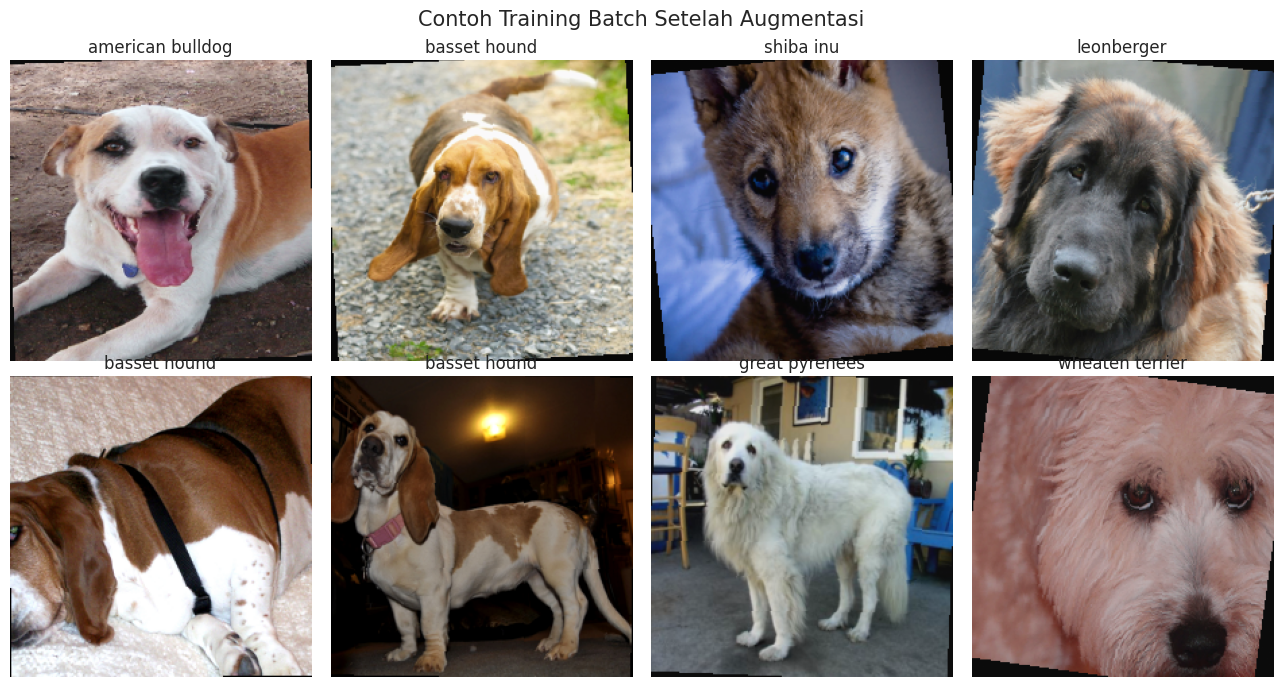

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/02_training_augmentation_examples.png


56

In [21]:
def denormalize_image(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


fig, axes = plt.subplots(2, 4, figsize=(13, 7))
axes = axes.flatten()

for axis, image_tensor, label in zip(axes, images[:8], labels[:8]):
    axis.imshow(denormalize_image(image_tensor).permute(1, 2, 0))
    axis.set_title(class_names[int(label)].replace("_", " "))
    axis.axis("off")

fig.suptitle("Contoh Training Batch Setelah Augmentasi", fontsize=15)
plt.tight_layout()

augmentation_figure_path = FIGURE_DIR / "02_training_augmentation_examples.png"
plt.savefig(augmentation_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tersimpan:", augmentation_figure_path)

# Loader preview tidak dipakai kembali agar worker tidak tetap aktif.
del preview_train_loader, preview_val_loader, images, labels
gc.collect()

## 7. Definisi model

In [22]:
MODEL_DISPLAY_NAMES = {
    "resnet50": "ResNet50",
    "swin_t": "Swin Transformer-Tiny",
}


def build_model(model_name, num_classes=NUM_CLASSES, pretrained=True):
    if model_name == "resnet50":
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        model = resnet50(weights=weights)
        input_features = model.fc.in_features
        model.fc = nn.Linear(input_features, num_classes)

    elif model_name == "swin_t":
        weights = Swin_T_Weights.DEFAULT if pretrained else None
        model = swin_t(weights=weights)
        input_features = model.head.in_features
        model.head = nn.Linear(input_features, num_classes)

    else:
        raise ValueError(f"Model tidak dikenali: {model_name}")

    return model


def count_parameters(model):
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return total, trainable


architecture_rows = []
for model_name in CONFIG["models"]:
    temporary_model = build_model(model_name, pretrained=False)
    total_params, trainable_params = count_parameters(temporary_model)
    architecture_rows.append(
        {
            "model_key": model_name,
            "model": MODEL_DISPLAY_NAMES[model_name],
            "total_parameters": total_params,
            "trainable_parameters": trainable_params,
            "parameters_million": round(total_params / 1e6, 3),
        }
    )
    del temporary_model

architecture_summary = pd.DataFrame(architecture_rows)
display(architecture_summary)
gc.collect()

,model_key,model,total_parameters,trainable_parameters,parameters_million
0,resnet50,ResNet50,23583845,23583845,23.584
1,swin_t,Swin Transformer-Tiny,27547807,27547807,27.548


0

### Smoke test forward pass

In [23]:
smoke_input = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)

for model_name in CONFIG["models"]:
    smoke_model = build_model(model_name, pretrained=False).to(device)
    smoke_model.eval()

    with torch.inference_mode():
        smoke_output = smoke_model(smoke_input)

    print(
        f"{MODEL_DISPLAY_NAMES[model_name]:<24}",
        "output:",
        tuple(smoke_output.shape),
    )
    assert smoke_output.shape == (2, NUM_CLASSES)

    del smoke_model, smoke_output
    torch.cuda.empty_cache()

del smoke_input
gc.collect()
torch.cuda.empty_cache()

print("Forward pass kedua arsitektur berhasil.")

ResNet50                 output: (2, 37)
Swin Transformer-Tiny    output: (2, 37)
Forward pass kedua arsitektur berhasil.


## 8. Fungsi training dan validation

In [24]:
def compute_classification_metrics(targets, predictions):
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets,
        predictions,
        average="macro",
        zero_division=0,
    )
    accuracy = accuracy_score(targets, predictions)

    return {
        "accuracy": float(accuracy),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
    }


def run_epoch(
    model,
    data_loader,
    criterion,
    optimizer=None,
    scaler=None,
    description="Epoch",
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    progress_bar = tqdm(data_loader, desc=description, leave=False)

    for batch_images, batch_targets in progress_bar:
        batch_images = batch_images.to(
            device,
            non_blocking=True,
        )
        batch_targets = batch_targets.to(
            device,
            non_blocking=True,
        )

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=AMP_ENABLED,
            ):
                logits = model(batch_images)
                loss = criterion(logits, batch_targets)

            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                clip_grad_norm_(
                    model.parameters(),
                    max_norm=GRADIENT_CLIP_NORM,
                )
                scaler.step(optimizer)
                scaler.update()

        predictions = logits.argmax(dim=1)
        batch_size = batch_targets.size(0)

        running_loss += loss.item() * batch_size
        all_targets.extend(batch_targets.detach().cpu().tolist())
        all_predictions.extend(predictions.detach().cpu().tolist())

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
        )

    epoch_loss = running_loss / len(data_loader.dataset)
    metrics = compute_classification_metrics(
        all_targets,
        all_predictions,
    )
    metrics["loss"] = float(epoch_loss)

    return metrics

## 9. Checkpointing yang aman untuk runtime Colab

In [25]:
def atomic_torch_save(payload, destination):
    '''Simpan lokal terlebih dahulu lalu ganti file Drive setelah salinan utuh.'''
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    local_temporary = Path("/content") / f"{destination.name}.local_tmp"
    drive_temporary = Path(str(destination) + ".part")

    torch.save(payload, local_temporary)
    shutil.copy2(local_temporary, drive_temporary)
    drive_temporary.replace(destination)

    if local_temporary.exists():
        local_temporary.unlink()


def create_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except TypeError:
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def checkpoint_paths(model_name):
    return {
        "best": CHECKPOINT_DIR / f"{model_name}_best.pth",
        "last": CHECKPOINT_DIR / f"{model_name}_last.pth",
        "history": HISTORY_DIR / f"{model_name}_history.csv",
    }

## 10. Fungsi utama training

In [26]:
def train_one_model(model_name, resume_training=True):
    paths = checkpoint_paths(model_name)
    resume_available = resume_training and paths["last"].exists()

    print("=" * 80)
    print("MODEL:", MODEL_DISPLAY_NAMES[model_name])
    print("=" * 80)

    # Jika resume checkpoint tersedia, pretrained weights tidak perlu diunduh.
    set_seed(SEED)
    model = build_model(
        model_name,
        pretrained=not resume_available,
    ).to(device)

    total_params, trainable_params = count_parameters(model)

    criterion = nn.CrossEntropyLoss(
        label_smoothing=LABEL_SMOOTHING,
    )
    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
        eta_min=1e-6,
    )
    scaler = create_grad_scaler()

    _, _, train_loader, val_loader = create_dataloaders(SEED)

    start_epoch = 1
    best_val_macro_f1 = -np.inf
    best_epoch = 0
    patience_counter = 0
    history = []
    elapsed_before_resume = 0.0
    training_complete = False

    if resume_available:
        print("Memuat checkpoint terakhir:", paths["last"])
        checkpoint = torch.load(
            paths["last"],
            map_location=device,
            weights_only=False,
        )

        assert checkpoint["model_name"] == model_name
        assert checkpoint["num_classes"] == NUM_CLASSES

        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

        start_epoch = int(checkpoint["epoch"]) + 1
        best_val_macro_f1 = float(checkpoint["best_val_macro_f1"])
        best_epoch = int(checkpoint["best_epoch"])
        patience_counter = int(checkpoint["patience_counter"])
        history = checkpoint.get("history", [])
        elapsed_before_resume = float(
            checkpoint.get("total_training_seconds", 0.0)
        )
        training_complete = bool(
            checkpoint.get("training_complete", False)
        )

        print("Training dilanjutkan dari epoch:", start_epoch)
        print("Best validation macro-F1     :", f"{best_val_macro_f1:.4f}")

    if training_complete:
        print("Checkpoint menandai training sudah selesai; training dilewati.")

    session_start = time.perf_counter()

    if not training_complete:
        for epoch in range(start_epoch, MAX_EPOCHS + 1):
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            epoch_start = time.perf_counter()

            current_lr = optimizer.param_groups[0]["lr"]

            train_metrics = run_epoch(
                model,
                train_loader,
                criterion,
                optimizer=optimizer,
                scaler=scaler,
                description=f"{model_name} train {epoch:02d}",
            )

            val_metrics = run_epoch(
                model,
                val_loader,
                criterion,
                optimizer=None,
                scaler=None,
                description=f"{model_name} val {epoch:02d}",
            )

            if torch.cuda.is_available():
                torch.cuda.synchronize()
            epoch_seconds = time.perf_counter() - epoch_start

            epoch_record = {
                "epoch": epoch,
                "learning_rate": current_lr,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_macro_precision": train_metrics["macro_precision"],
                "train_macro_recall": train_metrics["macro_recall"],
                "train_macro_f1": train_metrics["macro_f1"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_precision": val_metrics["macro_precision"],
                "val_macro_recall": val_metrics["macro_recall"],
                "val_macro_f1": val_metrics["macro_f1"],
                "epoch_seconds": epoch_seconds,
            }
            history.append(epoch_record)

            improved = (
                val_metrics["macro_f1"]
                > best_val_macro_f1 + EARLY_STOPPING_MIN_DELTA
            )

            if improved:
                best_val_macro_f1 = val_metrics["macro_f1"]
                best_epoch = epoch
                patience_counter = 0

                best_payload = {
                    "model_name": model_name,
                    "model_display_name": MODEL_DISPLAY_NAMES[model_name],
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "val_metrics": val_metrics,
                    "num_classes": NUM_CLASSES,
                    "class_names": class_names,
                    "config": CONFIG,
                    "environment": ENVIRONMENT,
                    "total_parameters": total_params,
                    "trainable_parameters": trainable_params,
                }
                atomic_torch_save(best_payload, paths["best"])
            else:
                patience_counter += 1

            scheduler.step()

            total_training_seconds = (
                elapsed_before_resume
                + time.perf_counter()
                - session_start
            )

            should_stop = patience_counter >= EARLY_STOPPING_PATIENCE
            reached_last_epoch = epoch == MAX_EPOCHS

            last_payload = {
                "model_name": model_name,
                "model_display_name": MODEL_DISPLAY_NAMES[model_name],
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict(),
                "epoch": epoch,
                "best_epoch": best_epoch,
                "best_val_macro_f1": best_val_macro_f1,
                "patience_counter": patience_counter,
                "history": history,
                "total_training_seconds": total_training_seconds,
                "training_complete": bool(should_stop or reached_last_epoch),
                "num_classes": NUM_CLASSES,
                "class_names": class_names,
                "config": CONFIG,
                "environment": ENVIRONMENT,
                "total_parameters": total_params,
                "trainable_parameters": trainable_params,
            }
            atomic_torch_save(last_payload, paths["last"])
            pd.DataFrame(history).to_csv(paths["history"], index=False)

            marker = " *BEST*" if improved else ""
            print(
                f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
                f"train loss {train_metrics['loss']:.4f} | "
                f"train acc {train_metrics['accuracy']:.4f} | "
                f"val loss {val_metrics['loss']:.4f} | "
                f"val acc {val_metrics['accuracy']:.4f} | "
                f"val macro-F1 {val_metrics['macro_f1']:.4f} | "
                f"{epoch_seconds:.1f}s{marker}"
            )

            if should_stop:
                print(
                    "Early stopping: validation macro-F1 tidak membaik "
                    f"selama {EARLY_STOPPING_PATIENCE} epoch."
                )
                break

    history_df = pd.DataFrame(history)
    if history_df.empty:
        raise RuntimeError(f"Riwayat training {model_name} kosong.")

    # Pastikan file history memuat keadaan terakhir, termasuk setelah resume.
    history_df.to_csv(paths["history"], index=False)

    best_row = history_df.loc[history_df["val_macro_f1"].idxmax()]
    total_training_seconds = float(history_df["epoch_seconds"].sum())

    summary = {
        "model_key": model_name,
        "model": MODEL_DISPLAY_NAMES[model_name],
        "best_epoch": int(best_row["epoch"]),
        "epochs_completed": int(history_df["epoch"].max()),
        "best_val_loss": float(best_row["val_loss"]),
        "best_val_accuracy": float(best_row["val_accuracy"]),
        "best_val_macro_precision": float(
            best_row["val_macro_precision"]
        ),
        "best_val_macro_recall": float(best_row["val_macro_recall"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "training_time_seconds": total_training_seconds,
        "training_time_minutes": total_training_seconds / 60,
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "best_checkpoint": str(paths["best"]),
        "last_checkpoint": str(paths["last"]),
        "history_csv": str(paths["history"]),
    }

    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()

    return history_df, summary

## 11. Jalankan training

Secara default kedua model dilatih berurutan. Jika ingin menjalankan satu model
terlebih dahulu, ubah `MODELS_TO_RUN`, misalnya:

```python
MODELS_TO_RUN = ["resnet50"]
```

Setelah selesai, ubah menjadi `MODELS_TO_RUN = ["swin_t"]`. Checkpoint dan
history tetap tersimpan pada lokasi yang berbeda.

`RESUME_TRAINING = True` membuat notebook melanjutkan checkpoint terakhir jika
runtime sebelumnya terputus. Untuk mengulang eksperimen dari nol, hapus secara
manual file `*_last.pth`, `*_best.pth`, dan `*_history.csv` model terkait dari
Drive, lalu jalankan kembali. Notebook tidak menghapusnya otomatis.

In [27]:
MODELS_TO_RUN = ["resnet50", "swin_t"]
RESUME_TRAINING = True

unknown_models = set(MODELS_TO_RUN) - set(CONFIG["models"])
assert not unknown_models, f"Model tidak dikenali: {unknown_models}"

print("Model yang akan dilatih:", MODELS_TO_RUN)
print("Resume training         :", RESUME_TRAINING)

Model yang akan dilatih: ['resnet50', 'swin_t']
Resume training         : True


In [28]:
training_histories = {}
training_summaries = []

for model_name in MODELS_TO_RUN:
    history_df, summary = train_one_model(
        model_name,
        resume_training=RESUME_TRAINING,
    )
    training_histories[model_name] = history_df
    training_summaries.append(summary)

print("Seluruh model pada MODELS_TO_RUN selesai diproses.")

MODEL: ResNet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


resnet50 train 01:   0%|          | 0/161 [00:00<?, ?it/s]

resnet50 val 01:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 01/15 | train loss 1.7648 | train acc 0.7362 | val loss 0.9634 | val acc 0.9156 | val macro-F1 0.9138 | 78.1s *BEST*


...

swin_t val 05:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 05/15 | train loss 0.7800 | train acc 0.9757 | val loss 0.8336 | val acc 0.9410 | val macro-F1 0.9412 | 78.4s


swin_t train 06:   0%|          | 0/161 [00:00<?, ?it/s]

swin_t val 06:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 06/15 | train loss 0.7515 | train acc 0.9829 | val loss 0.8336 | val acc 0.9437 | val macro-F1 0.9427 | 78.6s
Early stopping: validation macro-F1 tidak membaik selama 4 epoch.
Seluruh model pada MODELS_TO_RUN selesai diproses.


## 12. Memuat history yang tersedia

In [29]:
# Cell ini juga dapat dijalankan pada sesi baru tanpa mengulang training.
available_histories = {}

for model_name in CONFIG["models"]:
    history_path = checkpoint_paths(model_name)["history"]
    if history_path.exists():
        available_histories[model_name] = pd.read_csv(history_path)
        print(
            f"{model_name}: {len(available_histories[model_name])} epoch "
            f"dari {history_path.name}"
        )
    else:
        print(f"{model_name}: history belum tersedia")

assert available_histories, "Belum ada history training yang dapat divisualisasikan."

resnet50: 12 epoch dari resnet50_history.csv
swin_t: 6 epoch dari swin_t_history.csv


## 13. Kurva training dan validation

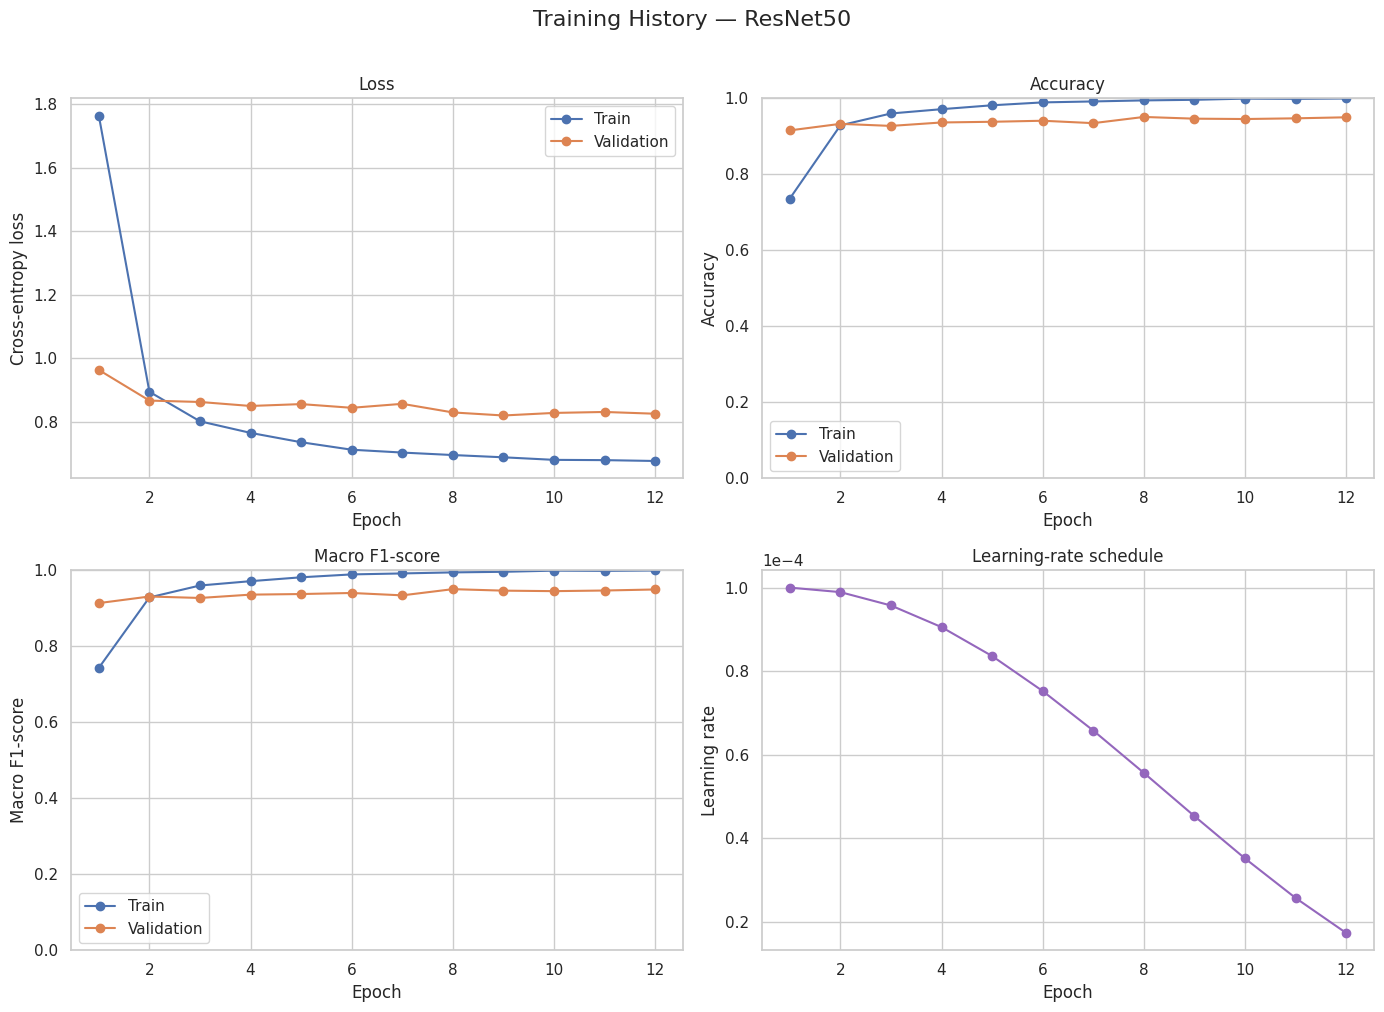

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/02_resnet50_training_curves.png


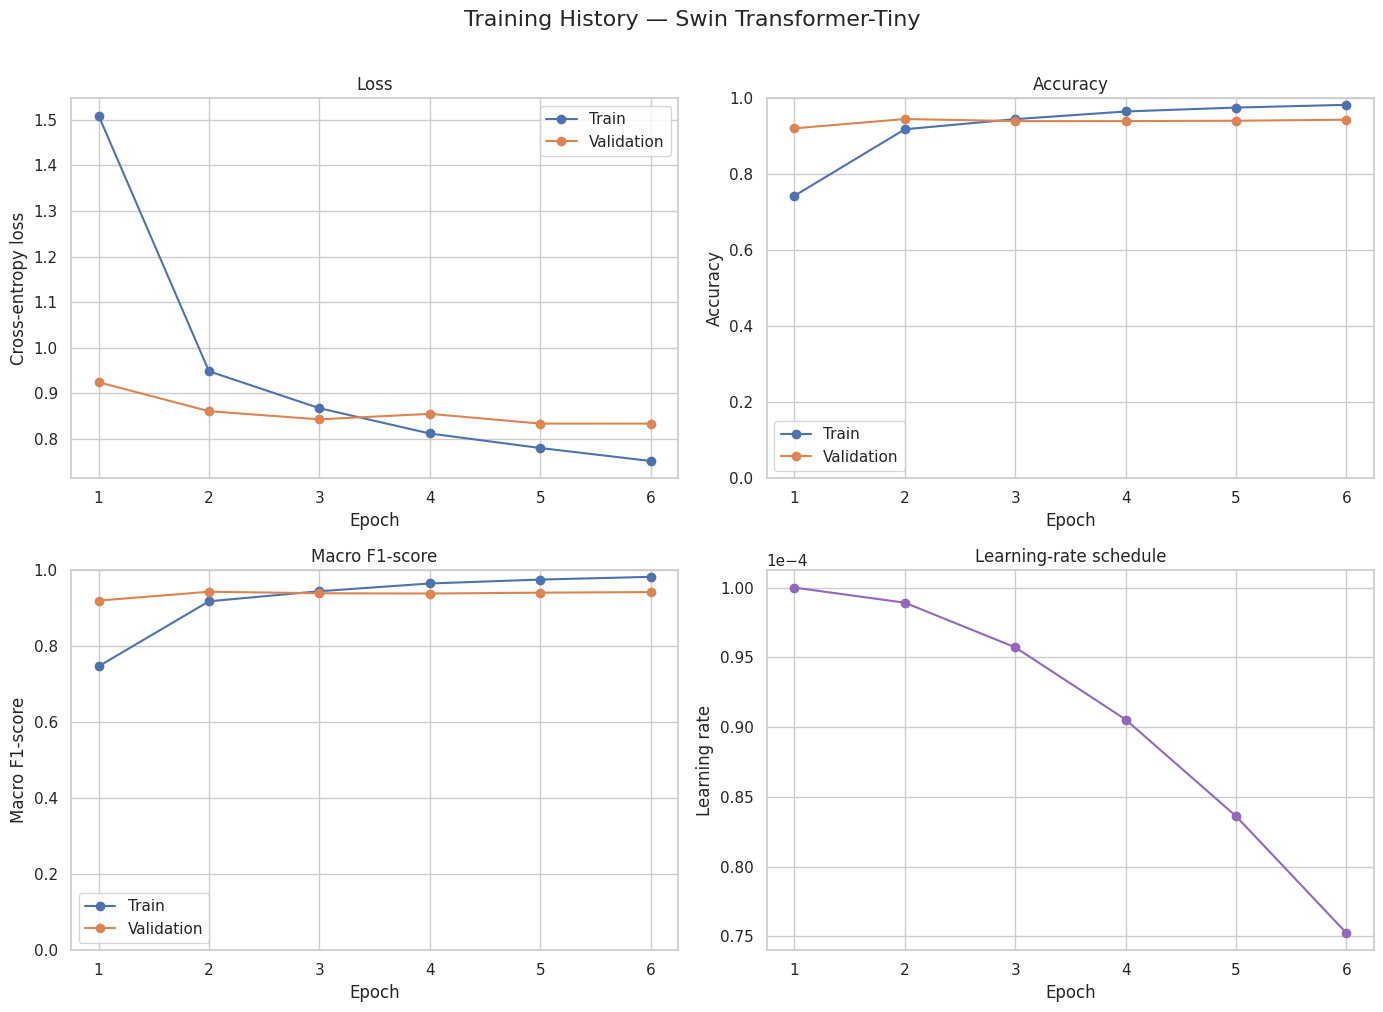

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/02_swin_t_training_curves.png


In [30]:
def plot_training_history(model_name, history_df):
    display_name = MODEL_DISPLAY_NAMES[model_name]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(
        history_df["epoch"],
        history_df["train_loss"],
        marker="o",
        label="Train",
    )
    axes[0, 0].plot(
        history_df["epoch"],
        history_df["val_loss"],
        marker="o",
        label="Validation",
    )
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Cross-entropy loss")
    axes[0, 0].legend()

    axes[0, 1].plot(
        history_df["epoch"],
        history_df["train_accuracy"],
        marker="o",
        label="Train",
    )
    axes[0, 1].plot(
        history_df["epoch"],
        history_df["val_accuracy"],
        marker="o",
        label="Validation",
    )
    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].legend()

    axes[1, 0].plot(
        history_df["epoch"],
        history_df["train_macro_f1"],
        marker="o",
        label="Train",
    )
    axes[1, 0].plot(
        history_df["epoch"],
        history_df["val_macro_f1"],
        marker="o",
        label="Validation",
    )
    axes[1, 0].set_title("Macro F1-score")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Macro F1-score")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].legend()

    axes[1, 1].plot(
        history_df["epoch"],
        history_df["learning_rate"],
        marker="o",
        color="#9467BD",
    )
    axes[1, 1].set_title("Learning-rate schedule")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Learning rate")
    axes[1, 1].ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))

    fig.suptitle(f"Training History — {display_name}", fontsize=16, y=1.01)
    plt.tight_layout()

    figure_path = FIGURE_DIR / f"02_{model_name}_training_curves.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Tersimpan:", figure_path)
    return figure_path


training_curve_paths = []
for model_name, history_df in available_histories.items():
    training_curve_paths.append(
        plot_training_history(model_name, history_df)
    )

### Perbandingan validation macro-F1

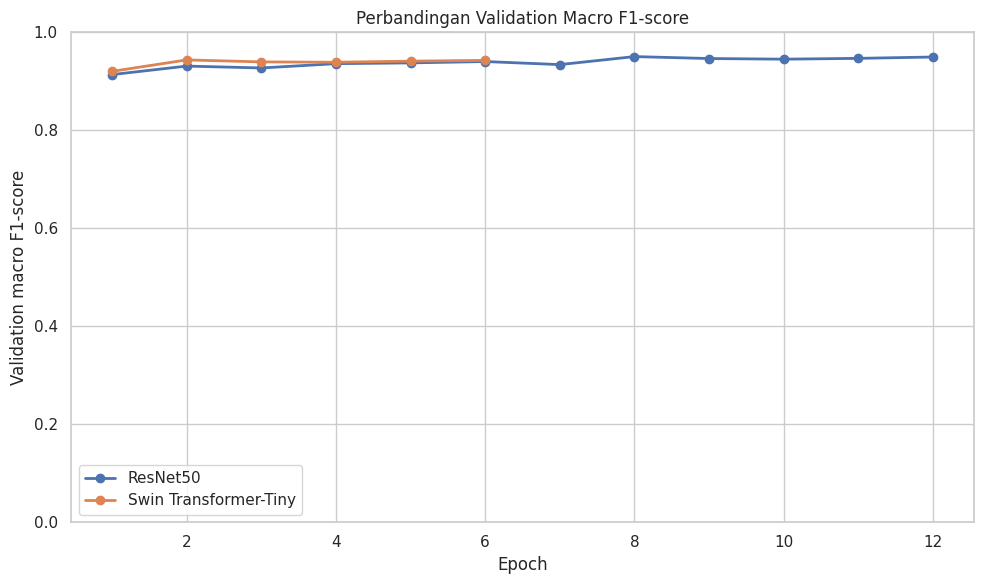

Tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures/02_validation_macro_f1_comparison.png


In [31]:
plt.figure(figsize=(10, 6))

for model_name, history_df in available_histories.items():
    plt.plot(
        history_df["epoch"],
        history_df["val_macro_f1"],
        marker="o",
        linewidth=2,
        label=MODEL_DISPLAY_NAMES[model_name],
    )

plt.title("Perbandingan Validation Macro F1-score")
plt.xlabel("Epoch")
plt.ylabel("Validation macro F1-score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

validation_comparison_path = (
    FIGURE_DIR / "02_validation_macro_f1_comparison.png"
)
plt.savefig(validation_comparison_path, dpi=300, bbox_inches="tight")
plt.show()

print("Tersimpan:", validation_comparison_path)

## 14. Ringkasan hasil training

In [32]:
summary_rows = []

for model_name, history_df in available_histories.items():
    best_row = history_df.loc[history_df["val_macro_f1"].idxmax()]

    temporary_model = build_model(model_name, pretrained=False)
    total_params, trainable_params = count_parameters(temporary_model)
    del temporary_model

    best_checkpoint_path = checkpoint_paths(model_name)["best"]
    last_checkpoint_path = checkpoint_paths(model_name)["last"]

    summary_rows.append(
        {
            "model_key": model_name,
            "model": MODEL_DISPLAY_NAMES[model_name],
            "best_epoch": int(best_row["epoch"]),
            "epochs_completed": int(history_df["epoch"].max()),
            "best_val_loss": float(best_row["val_loss"]),
            "best_val_accuracy": float(best_row["val_accuracy"]),
            "best_val_macro_precision": float(
                best_row["val_macro_precision"]
            ),
            "best_val_macro_recall": float(best_row["val_macro_recall"]),
            "best_val_macro_f1": float(best_row["val_macro_f1"]),
            "training_time_seconds": float(
                history_df["epoch_seconds"].sum()
            ),
            "training_time_minutes": float(
                history_df["epoch_seconds"].sum() / 60
            ),
            "total_parameters": total_params,
            "trainable_parameters": trainable_params,
            "best_checkpoint_mb": (
                best_checkpoint_path.stat().st_size / 1024**2
                if best_checkpoint_path.exists()
                else np.nan
            ),
            "best_checkpoint_exists": best_checkpoint_path.exists(),
            "last_checkpoint_exists": last_checkpoint_path.exists(),
        }
    )

training_summary_df = pd.DataFrame(summary_rows)

numeric_columns = [
    "best_val_loss",
    "best_val_accuracy",
    "best_val_macro_precision",
    "best_val_macro_recall",
    "best_val_macro_f1",
    "training_time_seconds",
    "training_time_minutes",
    "best_checkpoint_mb",
]
training_summary_df[numeric_columns] = training_summary_df[
    numeric_columns
].round(4)

training_summary_path = METRIC_DIR / "training_summary.csv"
training_summary_df.to_csv(training_summary_path, index=False)

display(training_summary_df)
print("Ringkasan tersimpan:", training_summary_path)

,model_key,model,best_epoch,epochs_completed,best_val_loss,best_val_accuracy,best_val_macro_precision,best_val_macro_recall,best_val_macro_f1,training_time_seconds,training_time_minutes,total_parameters,trainable_parameters,best_checkpoint_mb,best_checkpoint_exists,last_checkpoint_exists
0,resnet50,ResNet50,8,12,0.8296,0.9510,0.9517,0.9512,0.9505,938.6250,15.6438,23583845,23583845,90.2737,True,True
1,swin_t,Swin Transformer-Tiny,2,6,0.8608,0.9456,0.9493,0.9455,0.9437,468.2665,7.8044,27547807,27547807,105.3729,True,True


Ringkasan tersimpan: /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/metrics/training_summary.csv


Nilai pada tabel di atas masih merupakan **hasil validation**, bukan hasil
akhir pada test set. Model dengan validation macro-F1 terbaik pada masing-masing
arsitektur telah disimpan sebagai `resnet50_best.pth` dan `swin_t_best.pth`.
Kedua checkpoint itulah yang digunakan di notebook 03.

## 15. Verifikasi output akhir

In [33]:
expected_outputs = [
    config_path,
    training_summary_path,
    augmentation_figure_path,
    validation_comparison_path,
]

for model_name in available_histories:
    paths = checkpoint_paths(model_name)
    expected_outputs.extend(
        [
            paths["best"],
            paths["last"],
            paths["history"],
            FIGURE_DIR / f"02_{model_name}_training_curves.png",
        ]
    )

output_check = pd.DataFrame(
    [
        {
            "file": path.name,
            "folder": str(path.parent),
            "exists": path.exists(),
            "size_mb": (
                round(path.stat().st_size / 1024**2, 3)
                if path.exists()
                else np.nan
            ),
        }
        for path in expected_outputs
    ]
)

display(output_check)
assert output_check["exists"].all(), "Ada output training yang belum tersedia."

print("=" * 70)
print("NOTEBOOK 02 SELESAI")
print("=" * 70)
print("Model selesai       :", list(available_histories.keys()))
print("Checkpoint folder   :", CHECKPOINT_DIR)
print("History folder      :", HISTORY_DIR)
print("Metrics folder      :", METRIC_DIR)
print("Figure folder       :", FIGURE_DIR)
print()
print("Notebook 03 dapat menggunakan checkpoint *_best.pth.")

,file,folder,exists,size_mb
0,training_config.json,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/metrics,True,0.001
1,training_summary.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/metrics,True,0.000
2,02_training_augmentation_examples.png,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures,True,1.203
3,02_validation_macro_f1_comparison.png,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures,True,0.116
4,resnet50_best.pth,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/checkpoints,True,90.274
5,resnet50_last.pth,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/checkpoints,True,270.342
6,resnet50_history.csv,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/histories,True,0.003
7,02_resnet50_training_curves.png,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures,True,0.372
8,swin_t_best.pth,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/checkpoints,True,105.373
9,swin_t_last.pth,/content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/checkpoints,True,315.689


NOTEBOOK 02 SELESAI
Model selesai       : ['resnet50', 'swin_t']
Checkpoint folder   : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/checkpoints
History folder      : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/histories
Metrics folder      : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/metrics
Figure folder       : /content/drive/MyDrive/Binus/Sem2Per1_DeepLearningandItsApplication/AoL1_ComputerVision/outputs/figures

Notebook 03 dapat menggunakan checkpoint *_best.pth.
